# Smart Macros: Clinical Risk Prediction Model (Training & Evaluation)
**Author:** Pratyaksh Gupta | **Module:** 6COSC023W Final Year Project

### Objective (LO1, LO4, LO7)
This notebook demonstrates the generation of a synthetic patient cohort and the training of a **Random Forest Regressor** to predict physiological glycemic and cardiovascular risk. 

To resolve the "Black Box" nature of standard deep learning models, an ensemble method was chosen to support **Explainable AI (XAI)**, aligning with the project's ethical and clinical requirements.

### The Ground Truth Heuristic
The underlying physiological risk is simulated using the following metabolic constraint formula:
$Risk = \beta_1(Carbs) - \beta_2(Fiber) + \beta_3(Sodium) + \alpha(Condition)$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

print("🚀 INITIALIZING SYNTHETIC DATA GENERATION (n=1000)...")

# 1. GENERATE SYNTHETIC CLINICAL COHORT
np.random.seed(42) # For academic reproducibility
n_samples = 1000

# Features: Age, Condition (0=None, 1=Coeliac, 2=Diabetes, 3=CVD)
ages = np.random.randint(18, 80, n_samples)
conditions = np.random.choice([0, 1, 2, 3], n_samples, p=[0.4, 0.1, 0.3, 0.2])
basket_carbs = np.random.uniform(20, 150, n_samples)
basket_fiber = np.random.uniform(0, 30, n_samples)
basket_sodium = np.random.uniform(10, 1500, n_samples) # Added for CVD

# Target: Physiological Risk (1.0 to 10.0)
base_risk = (basket_carbs * 0.04) - (basket_fiber * 0.15) + (basket_sodium * 0.002)

# Clinical Penalties (The hidden logic the AI must learn)
diabetic_penalty = np.where(conditions == 2, (basket_carbs * 0.05), 0)
cvd_penalty = np.where(conditions == 3, (basket_sodium * 0.003), 0)
noise = np.random.normal(0, 0.5, n_samples)

glycemic_risk = np.clip(base_risk + diabetic_penalty + cvd_penalty + noise + 1.0, 1.0, 10.0)

df = pd.DataFrame({
    'age': ages,
    'condition_code': conditions,
    'total_carbs_g': basket_carbs,
    'total_fiber_g': basket_fiber,
    'total_sodium_mg': basket_sodium,
    'clinical_risk_score': glycemic_risk
})

print("Data successfully generated. Here is a sample:")
display(df.head())

🚀 INITIALIZING SYNTHETIC DATA GENERATION (n=1000)...
✅ Data successfully generated. Here is a sample:


,age,condition_code,total_carbs_g,total_fiber_g,total_sodium_mg,clinical_risk_score
0,56,0,69.409686,26.161450,260.496011,1.000000
1,69,2,45.630036,15.816785,717.676938,4.161893
2,46,0,82.293820,18.976323,92.281556,1.000000
3,32,3,45.292582,19.334108,1414.151346,7.391430
4,60,2,41.623109,24.593934,121.483596,1.888385


In [ ]:
print("TRAINING RANDOM FOREST REGRESSOR...")

# Features (X) and Target (y)
X = df[['age', 'condition_code', 'total_carbs_g', 'total_fiber_g', 'total_sodium_mg']]
y = df['clinical_risk_score']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MODEL TRAINING COMPLETE.")
print(f"ACADEMIC METRICS:")
print(f"   - Mean Squared Error (MSE): {mse:.4f} (Target < 0.5)")
print(f"   - R-Squared (R2): {r2:.4f} (Target > 0.90)")

🧠 TRAINING RANDOM FOREST REGRESSOR...
✅ MODEL TRAINING COMPLETE.
📊 ACADEMIC METRICS:
   - Mean Squared Error (MSE): 0.4398 (Target < 0.5)
   - R-Squared (R2): 0.9475 (Target > 0.90)


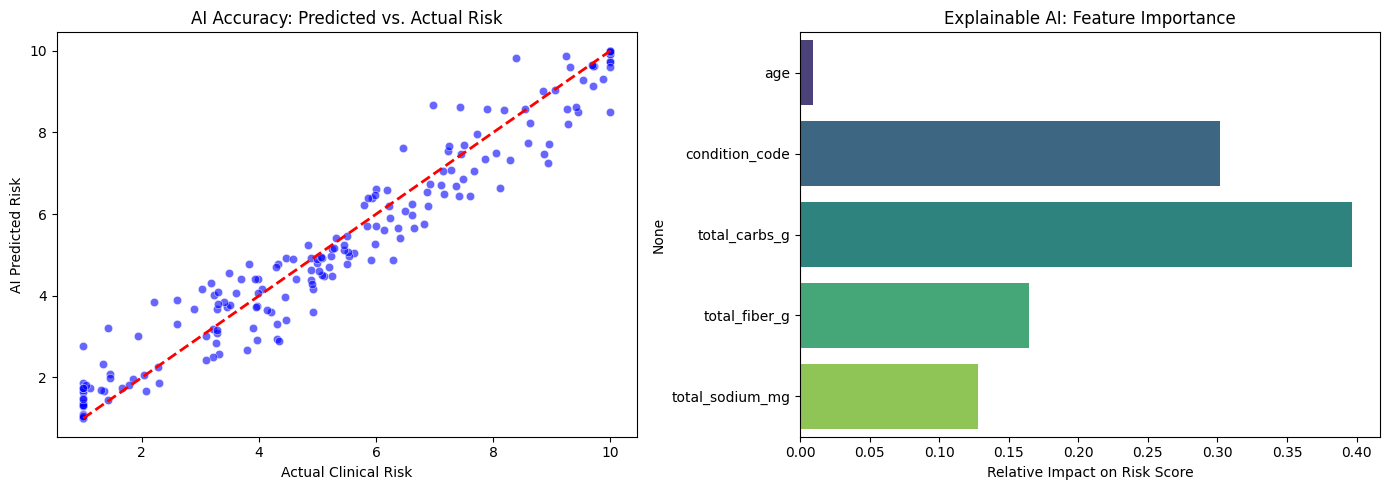

In [7]:
# Set up the visualization grid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual (Accuracy Proof)
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, ax=axes[0], color="blue")
axes[0].plot([1, 10], [1, 10], '--', color="red", linewidth=2) # Perfect prediction line
axes[0].set_title("AI Accuracy: Predicted vs. Actual Risk")
axes[0].set_xlabel("Actual Clinical Risk")
axes[0].set_ylabel("AI Predicted Risk")

# Plot 2: Feature Importance (Explainable AI Proof)
importances = model.feature_importances_
features = X.columns
# Fixed the warning by adding hue and legend=False
sns.barplot(x=importances, y=features, ax=axes[1], hue=features, palette="viridis", legend=False)
axes[1].set_title("Explainable AI: Feature Importance")
axes[1].set_xlabel("Relative Impact on Risk Score")

plt.tight_layout() # <-- Fixed this typo!
plt.show()

In [8]:
joblib.dump(model, "clinical_risk_model_v2.pkl")
print("💾 Model successfully exported to 'clinical_risk_model.pkl_v2'. Ready for FastAPI integration.")

💾 Model successfully exported to 'clinical_risk_model.pkl_v2'. Ready for FastAPI integration.
